# Seminar 05: CNNs From First Principles on FashionMNIST

**Student Version**

Goals for today:
- Reason about image tensors shaped **[B, C, H, W]**
- Track how convolution, activation, and pooling change feature maps
- Build a CNN from a verbal architecture description
- Compare CNN and MLP behavior without repeating training-loop boilerplate
- Inspect mistakes and feature maps to understand what the CNN is doing


## 0. Setup


In [1]:
import math
import random
import time
from dataclasses import dataclass

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt


def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


seed_everything(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device


device(type='cpu')

### Configuration


In [2]:
@dataclass
class Config:
    seed: int = 42
    train_n: object = 12000
    val_n: int = 2000
    batch_size: int = 128
    lr: float = 1e-3
    epochs: int = 5


cfg = Config()
cfg


Config(seed=42, train_n=12000, val_n=2000, batch_size=128, lr=0.001, epochs=5)

### Helpers


In [3]:
CLASS_NAMES = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


def show_images(images, labels=None, preds=None, class_names=None, nrow=8, figsize=(12, 4)):
    images = images.detach().cpu()
    n_images = images.shape[0]
    ncol = int(math.ceil(n_images / nrow))
    plt.figure(figsize=figsize)
    for i in range(n_images):
        plt.subplot(ncol, nrow, i + 1)
        if images.shape[1] == 1:
            plt.imshow(images[i, 0], cmap='gray')
        else:
            plt.imshow(images[i].permute(1, 2, 0).numpy())
        plt.axis('off')
        title = None
        if labels is not None:
            y = int(labels[i])
            title = class_names[y] if class_names is not None else str(y)
        if preds is not None:
            p = int(preds[i])
            pred_txt = class_names[p] if class_names is not None else str(p)
            title = f'{title}\n-> {pred_txt}' if title is not None else pred_txt
        if title is not None:
            plt.title(title, fontsize=8)
    plt.tight_layout()
    plt.show()


@torch.no_grad()
def accuracy_multiclass(logits, y_true):
    preds = logits.argmax(dim=1)
    return (preds == y_true).float().mean().item()


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def empty_history():
    return {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}


def plot_history(history, title_prefix=''):
    epochs = range(1, len(history['train_loss']) + 1)
    plt.figure()
    plt.plot(epochs, history['train_loss'], label='train')
    plt.plot(epochs, history['val_loss'], label='val')
    plt.title(f'{title_prefix}Loss')
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(epochs, history['train_acc'], label='train')
    plt.plot(epochs, history['val_acc'], label='val')
    plt.title(f'{title_prefix}Accuracy')
    plt.xlabel('epoch')
    plt.ylabel('accuracy')
    plt.legend()
    plt.show()


def summarize_run(name, model, history, elapsed_sec):
    return {
        'name': name,
        'params': count_parameters(model),
        'best_val_acc': float(max(history['val_acc'])),
        'final_val_acc': float(history['val_acc'][-1]),
        'final_train_acc': float(history['train_acc'][-1]),
        'elapsed_sec': float(elapsed_sec),
    }


## 1. Provided data setup

FashionMNIST loading is infrastructure today. The seminar starts from inspecting the image tensor convention.


100%|██████████| 26.4M/26.4M [00:01<00:00, 14.2MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 210kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.90MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 2.64MB/s]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


xb: torch.Size([128, 1, 28, 28]) torch.float32 min/max: 0.0 1.0
yb: torch.Size([128]) torch.int64


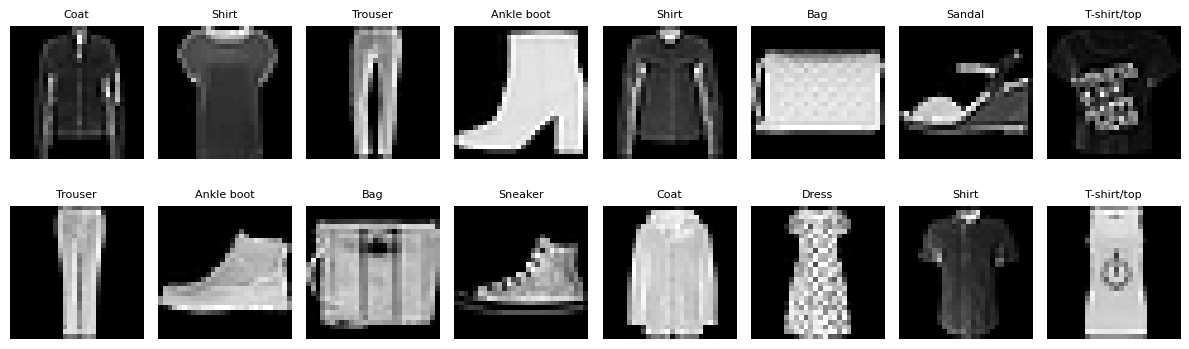

In [4]:
def build_fashionmnist_loaders(cfg):
    transform = transforms.Compose([transforms.ToTensor()])
    train_full = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)

    generator = torch.Generator().manual_seed(cfg.seed)
    perm = torch.randperm(len(train_full), generator=generator)
    val_idx = perm[:cfg.val_n]
    train_idx = perm[cfg.val_n:]
    if cfg.train_n is not None:
        train_idx = train_idx[:cfg.train_n]

    train_ds = Subset(train_full, train_idx.tolist())
    val_ds = Subset(train_full, val_idx.tolist())

    train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=256, shuffle=False, num_workers=2, pin_memory=True)
    return train_loader, val_loader, train_idx, val_idx


train_loader, val_loader, train_idx, val_idx = build_fashionmnist_loaders(cfg)
xb, yb = next(iter(train_loader))

print('xb:', xb.shape, xb.dtype, 'min/max:', float(xb.min()), float(xb.max()))
print('yb:', yb.shape, yb.dtype)
show_images(xb[:16], labels=yb[:16], class_names=CLASS_NAMES, nrow=8, figsize=(12, 4))

assert xb.ndim == 4 and xb.shape[1:] == (1, 28, 28)
assert yb.ndim == 1 and yb.dtype in (torch.int64, torch.long)
assert len(set(train_idx.tolist()).intersection(set(val_idx.tolist()))) == 0


## 2. Exercise 1: Convolution Shape Lab

Create a fake batch from this description:

> A batch of 4 grayscale images. Each image is 28 pixels high and 28 pixels wide.

Use PyTorch image tensor convention. Then pass it through two CNN blocks:
- first block: convolution creates 8 feature maps, then ReLU, then 2x2 max-pooling
- second block: convolution creates 16 feature maps, then ReLU, then 2x2 max-pooling

Basic `Conv2d` contract:
```python
nn.Conv2d(in_channels, out_channels, kernel_size, stride=1, padding=0)
```

Use `kernel_size=3` and padding that preserves height/width before pooling.

Fill the fake batch, layers, intermediate tensors, and `flatten_dim`. The expected `shape_trace` is already written, so use it as the target while you debug.

At the end, inspect the learnable parameter count for each layer and the total parameter count of this tiny convolution stack.


In [6]:
# Exercise 1

x_fake = torch.randn(4,1,28,28)
conv1 = nn.Conv2d(in_channels=1, out_channels=8, kernel_size=3, stride=1, padding=1)
relu = nn.ReLU()
pool = nn.MaxPool2d(kernel_size=2)
conv2 = nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3, stride=1, padding=1)

h_conv1 = conv1(x_fake)
h_relu1 = relu(h_conv1)
h_pool1 = pool(h_relu1)
h_conv2 = conv2(h_pool1)
h_relu2 = relu(h_conv2)
h_pool2 = pool(h_relu2)

shape_trace = {
    'input': (4, 1, 28, 28),
    'conv1': (4, 8, 28, 28),
    'relu1': (4, 8, 28, 28),
    'pool1': (4, 8, 14, 14),
    'conv2': (4, 16, 14, 14),
    'relu2': (4, 16, 14, 14),
    'pool2': (4, 16, 7, 7),
}

actual_shape_trace = {
    'input': tuple(x_fake.shape),
    'conv1': tuple(h_conv1.shape),
    'relu1': tuple(h_relu1.shape),
    'pool1': tuple(h_pool1.shape),
    'conv2': tuple(h_conv2.shape),
    'relu2': tuple(h_relu2.shape),
    'pool2': tuple(h_pool2.shape),
}

flatten_dim = 16 * 7 * 7

param_counts = {
    'conv1': count_parameters(conv1),
    'relu': count_parameters(relu),
    'pool': count_parameters(pool),
    'conv2': count_parameters(conv2),
}
param_counts['total'] = sum(param_counts.values())

print('expected shapes:', shape_trace)
print('actual shapes  :', actual_shape_trace)
print('flatten_dim:', flatten_dim)
print('parameter counts:', param_counts)

assert actual_shape_trace == shape_trace
assert flatten_dim == 16 * 7 * 7
assert param_counts == {
    'conv1': 80,
    'relu': 0,
    'pool': 0,
    'conv2': 1168,
    'total': 1248,
}


expected shapes: {'input': (4, 1, 28, 28), 'conv1': (4, 8, 28, 28), 'relu1': (4, 8, 28, 28), 'pool1': (4, 8, 14, 14), 'conv2': (4, 16, 14, 14), 'relu2': (4, 16, 14, 14), 'pool2': (4, 16, 7, 7)}
actual shapes  : {'input': (4, 1, 28, 28), 'conv1': (4, 8, 28, 28), 'relu1': (4, 8, 28, 28), 'pool1': (4, 8, 14, 14), 'conv2': (4, 16, 14, 14), 'relu2': (4, 16, 14, 14), 'pool2': (4, 16, 7, 7)}
flatten_dim: 784
parameter counts: {'conv1': 80, 'relu': 0, 'pool': 0, 'conv2': 1168, 'total': 1248}


## 3. Exercise 2: Build the CNN

Implement `SimpleCNN` from a verbal architecture description.

Architecture:
- input is a grayscale FashionMNIST image batch
- first convolution block produces 8 feature maps
- second convolution block receives those 8 maps and produces 16 feature maps
- both convolutions use 3x3 kernels and preserve spatial size before pooling
- each block uses ReLU and 2x2 max-pooling
- the classifier receives the flattened tensor after two pooling operations and outputs logits for 10 classes

Basic layer contracts:
```python
nn.Conv2d(in_channels, out_channels, kernel_size, stride=1, padding=1)
nn.MaxPool2d(kernel_size)
nn.Linear(in_features, out_features)
```

Contract for your model:
- `model(x)` returns logits shaped `[B, 10]`
- `model(x, return_features=True)` returns `(logits, features)`
- `features` contains `conv1`, `pool1`, `conv2`, `pool2`


In [9]:
# Exercise 2

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 8, 3, 1, 1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(8, 16, 3, 1, 1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2)
        self.classifier = nn.Linear(16*7*7, 10)

    def forward(self, x, return_features=False):
        features = {}
        logits = self.conv1(x)
        features['conv1'] = logits

        logits = self.relu1(logits)

        logits = self.pool1(logits)
        features['pool1'] = logits

        logits = self.conv2(logits)
        features['conv2'] = logits

        logits = self.relu2(logits)

        logits = self.pool2(logits)
        features['pool2'] = logits

        logits = torch.flatten(logits, start_dim=1)
        logits = self.classifier(logits)
        if return_features:
            return logits, features
        return logits


cnn = SimpleCNN().to(device)
with torch.no_grad():
    logits, features = cnn(xb[:8].to(device), return_features=True)

feature_shapes = {name: tuple(value.shape) for name, value in features.items()}
print('logits:', logits.shape)
print('features:', feature_shapes)
print('parameters:', count_parameters(cnn))

assert logits.shape == (8, 10)
assert feature_shapes == {
    'conv1': (8, 8, 28, 28),
    'pool1': (8, 8, 14, 14),
    'conv2': (8, 16, 14, 14),
    'pool2': (8, 16, 7, 7),
}
assert count_parameters(cnn) < 20000


logits: torch.Size([8, 10])
features: {'conv1': (8, 8, 28, 28), 'pool1': (8, 8, 14, 14), 'conv2': (8, 16, 14, 14), 'pool2': (8, 16, 7, 7)}
parameters: 9098


## 4. CNN vs MLP


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


cnn        epoch 01 | train 1.2503/0.597 | val 0.7939/0.726
cnn        epoch 02 | train 0.6617/0.757 | val 0.6567/0.761
cnn        epoch 03 | train 0.5647/0.793 | val 0.5715/0.792
cnn        epoch 04 | train 0.5052/0.819 | val 0.5426/0.809
cnn        epoch 05 | train 0.4692/0.830 | val 0.5116/0.818


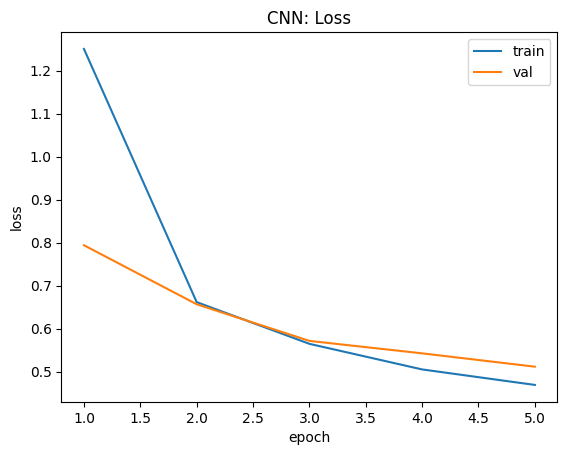

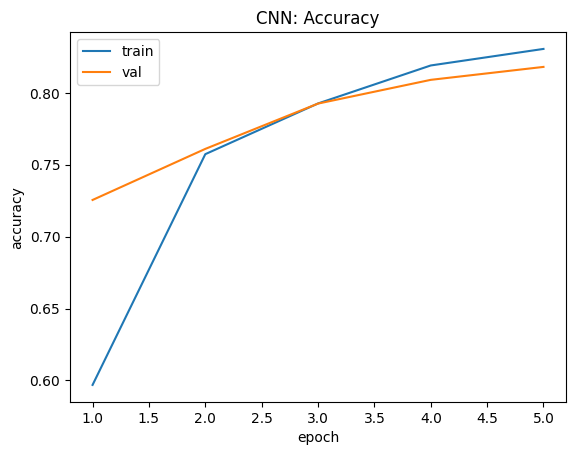

mlp        epoch 01 | train 0.8509/0.710 | val 0.6133/0.784
mlp        epoch 02 | train 0.5370/0.811 | val 0.5690/0.799
mlp        epoch 03 | train 0.4717/0.834 | val 0.5288/0.816
mlp        epoch 04 | train 0.4380/0.846 | val 0.4813/0.834
mlp        epoch 05 | train 0.4063/0.855 | val 0.4838/0.839


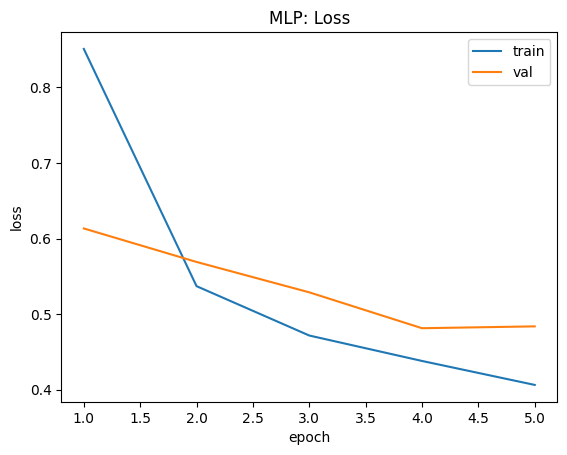

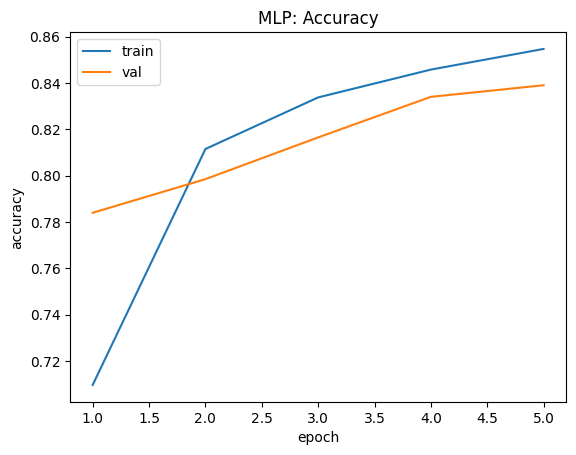

{'name': 'cnn', 'params': 9098, 'best_val_acc': 0.8180000019073487, 'final_val_acc': 0.8180000019073487, 'final_train_acc': 0.8304999998410543, 'elapsed_sec': 24.897921085357666}
{'name': 'mlp', 'params': 203530, 'best_val_acc': 0.8390000019073486, 'final_val_acc': 0.8390000019073486, 'final_train_acc': 0.8546666668256124, 'elapsed_sec': 12.155776262283325}
CNN has fewer parameters: True
CNN best val acc: 0.8180000019073487
MLP best val acc: 0.8390000019073486


In [10]:
loss_fn = nn.CrossEntropyLoss()


def train_one_epoch(model, loader, opt, loss_fn):
    model.train()
    total_loss = 0.0
    total_acc = 0.0
    total_n = 0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)
        opt.zero_grad()
        logits = model(xb)
        loss = loss_fn(logits, yb)
        loss.backward()
        opt.step()

        bs = xb.shape[0]
        total_loss += loss.item() * bs
        total_acc += accuracy_multiclass(logits.detach(), yb) * bs
        total_n += bs

    return total_loss / total_n, total_acc / total_n


@torch.no_grad()
def evaluate(model, loader, loss_fn):
    model.eval()
    total_loss = 0.0
    total_acc = 0.0
    total_n = 0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)
        logits = model(xb)
        loss = loss_fn(logits, yb)

        bs = xb.shape[0]
        total_loss += loss.item() * bs
        total_acc += accuracy_multiclass(logits, yb) * bs
        total_n += bs

    return total_loss / total_n, total_acc / total_n


def run_training(name, model, cfg, train_loader, val_loader):
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=cfg.lr)
    history = empty_history()
    started = time.time()

    for epoch in range(1, cfg.epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, opt, loss_fn)
        va_loss, va_acc = evaluate(model, val_loader, loss_fn)
        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(va_loss)
        history['val_acc'].append(va_acc)
        print(f'{name:10s} epoch {epoch:02d} | train {tr_loss:.4f}/{tr_acc:.3f} | val {va_loss:.4f}/{va_acc:.3f}')

    elapsed_sec = time.time() - started
    return {'name': name, 'model': model, 'history': history, 'elapsed_sec': elapsed_sec}


class SimpleMLP(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.net(x)


seed_everything(cfg.seed)
cnn_result = run_training('cnn', SimpleCNN(), cfg, train_loader, val_loader)
plot_history(cnn_result['history'], title_prefix='CNN: ')
cnn_summary = summarize_run('cnn', cnn_result['model'], cnn_result['history'], cnn_result['elapsed_sec'])

seed_everything(cfg.seed)
mlp_result = run_training('mlp', SimpleMLP(), cfg, train_loader, val_loader)
plot_history(mlp_result['history'], title_prefix='MLP: ')
mlp_summary = summarize_run('mlp', mlp_result['model'], mlp_result['history'], mlp_result['elapsed_sec'])

comparison_rows = [cnn_summary, mlp_summary]
for row in comparison_rows:
    print(row)

print('CNN has fewer parameters:', cnn_summary['params'] < mlp_summary['params'])
print('CNN best val acc:', cnn_summary['best_val_acc'])
print('MLP best val acc:', mlp_summary['best_val_acc'])


In [12]:
cnn_summary['params'], mlp_summary['params']

(9098, 203530)

## 5. Exercise 3: Collect Predictions

Implement `collect_predictions(model, loader)` for the trained CNN.

Contract:
- output dict keys: `images`, `y_true`, `y_pred`, `probs`
- `images` shape `[N, 1, 28, 28]`
- `y_true` and `y_pred` shape `[N]`
- `probs` shape `[N, 10]`

Useful hint: `torch.softmax(logits, dim=1)` converts logits to class probabilities.


In [14]:
# Exercise 3

@torch.no_grad()
def collect_predictions(model, loader):
    model.eval()
    images, y_true, y_pred, probs = [], [], [], []

    for xb, yb in loader:
        logits = model(xb.to(device))
        batch_probs = torch.softmax(logits, dim=1).cpu()
        batch_pred = batch_probs.argmax(dim=1)
        images.append(xb.cpu())
        y_true.append(yb.cpu())
        y_pred.append(batch_pred.cpu())
        probs.append(batch_probs)

    return {
        'images': torch.cat(images, dim=0),
        'y_true': torch.cat(y_true, dim=0),
        'y_pred': torch.cat(y_pred, dim=0),
        'probs': torch.cat(probs, dim=0),
    }


preds = collect_predictions(cnn_result['model'], val_loader)

assert set(preds.keys()) == {'images', 'y_true', 'y_pred', 'probs'}
assert preds['images'].ndim == 4 and preds['images'].shape[1:] == (1, 28, 28)
assert preds['y_true'].shape == preds['y_pred'].shape
assert preds['probs'].shape == (preds['y_true'].shape[0], 10)
assert torch.allclose(preds['probs'].sum(dim=1), torch.ones(preds['probs'].shape[0]), atol=1e-5)
assert preds['images'].shape[0] == len(val_loader.dataset)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


## 6. Exercise 4: Mistake Gallery and Per-Class Accuracy

Use the collected predictions to inspect model behavior.

Fill:
- `mistake_idx`, `mistake_images`, `mistake_true`, `mistake_pred`
- `per_class_correct`, `per_class_total`, `per_class_accuracy`
- `hardest_class_idx`

Useful hints:
- `mask.nonzero(as_tuple=False).reshape(-1)` gives indices where a boolean mask is true
- `torch.bincount(labels, minlength=10)` is useful for class counts
- `per_class_total.clamp_min(1)` replaces zeros by ones, so division cannot crash for a class with no examples
- visualize mistakes with `show_images(images, labels=true, preds=pred, class_names=CLASS_NAMES)`


Tip: avoid division-by-zero when computing per-class accuracy by clamping class counts to at least 1.

```python
# compute totals and avoid zeros
per_class_total = torch.bincount(y_true, minlength=10)
per_class_correct = torch.bincount(y_true[correct_mask], minlength=10)



In [ ]:
# Exercise 4

wrong_mask = None
mistake_idx = None
mistake_images = None
mistake_true = None
mistake_pred = None

per_class_correct = None
per_class_total = None
per_class_accuracy = None
hardest_class_idx = None

# Visualize up to 24 mistakes and print per-class accuracy.

assert mistake_images.shape[0] <= 24
assert mistake_images.ndim == 4 and mistake_images.shape[1:] == (1, 28, 28)
assert mistake_true.shape == mistake_pred.shape
assert per_class_correct.shape == (10,)
assert per_class_total.shape == (10,)
assert per_class_accuracy.shape == (10,)
assert 0 <= hardest_class_idx < 10

print('Hardest class:', hardest_class_idx, CLASS_NAMES[hardest_class_idx], float(per_class_accuracy[hardest_class_idx]))


## 7. Exercise 5: Feature Maps

Visualize what the trained CNN produces inside the network.

Fill:
- `first_layer_weights`: learned filters shaped `[8, 1, 3, 3]`
- plots of all first-layer filters
- `conv1_maps`: 8 early feature maps for one validation image
- `conv2_maps`: 16 deeper feature maps for the same image

Useful observations:
- early feature maps are often easier to visually interpret
- deeper feature maps can look less pretty but be more useful for classification


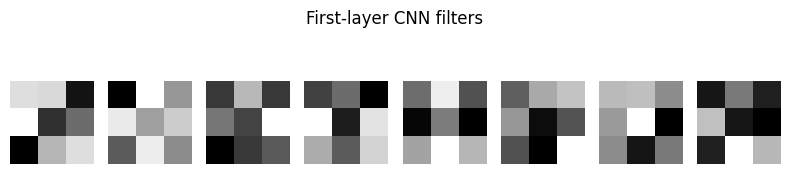

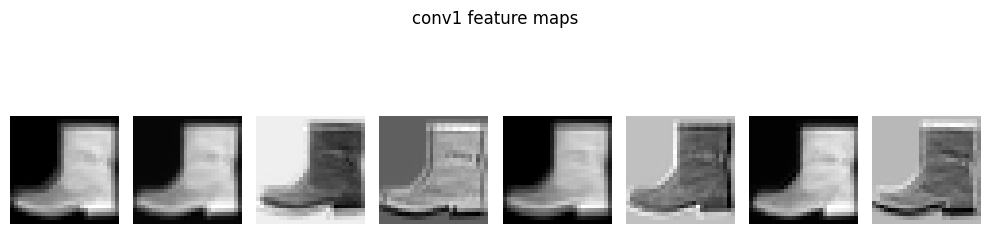

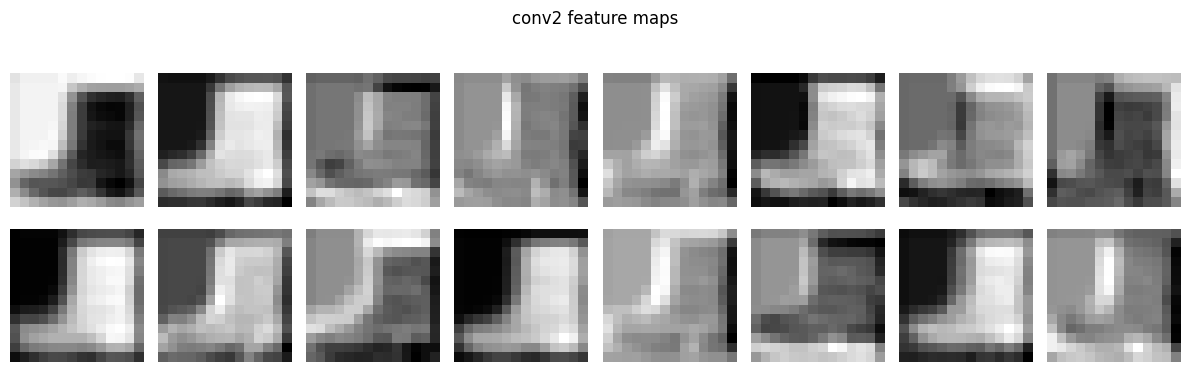

In [15]:
# Exercise 5

trained_cnn = cnn_result['model']
first_layer_weights = trained_cnn.conv1.weight.detach().cpu()

plt.figure(figsize=(8, 2))
for i in range(first_layer_weights.shape[0]):
    plt.subplot(1, first_layer_weights.shape[0], i + 1)
    plt.imshow(first_layer_weights[i, 0], cmap='gray')
    plt.axis('off')
plt.suptitle('First-layer CNN filters')
plt.tight_layout()
plt.show()

one_image = preds['images'][:1].to(device)
with torch.no_grad():
    one_image_logits, one_image_features = trained_cnn(one_image, return_features=True)
conv1_maps = one_image_features['conv1'].detach().cpu()
conv2_maps = one_image_features['conv2'].detach().cpu()

plt.figure(figsize=(10, 3))
for i in range(conv1_maps.shape[1]):
    plt.subplot(1, conv1_maps.shape[1], i + 1)
    plt.imshow(conv1_maps[0, i], cmap='gray')
    plt.axis('off')
plt.suptitle('conv1 feature maps')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
for i in range(conv2_maps.shape[1]):
    plt.subplot(2, 8, i + 1)
    plt.imshow(conv2_maps[0, i], cmap='gray')
    plt.axis('off')
plt.suptitle('conv2 feature maps')
plt.tight_layout()
plt.show()

assert first_layer_weights.shape == (8, 1, 3, 3)
assert one_image.shape == (1, 1, 28, 28)
assert one_image_logits.shape == (1, 10)
assert conv1_maps.shape == (1, 8, 28, 28)
assert conv2_maps.shape == (1, 16, 14, 14)


## 8. Optional discussion: CIFAR-10

What changes if we move from FashionMNIST to CIFAR-10?
- input channels: `1 -> 3`
- image size: `28x28 -> 32x32`
- after two pools: `32 -> 16 -> 8`, so flatten size becomes `16 * 8 * 8`
- the same tiny CNN is usually not strong enough


## 9. Wrap-up questions
1. Why is a CNN usually better suited to images than an MLP?
2. Why does padding matter before pooling?
3. What is the flatten size in this CNN and why?
4. Did the CNN use fewer parameters than the MLP?
5. Did fewer parameters automatically mean better validation accuracy?
6. Which classes were hardest, and do the mistakes look visually reasonable?
7. How do `conv1` and `conv2` feature maps differ visually?
